# Despliegue de un Modelo de Clasificación como Servicio Web con FastAPI

**Universidad:** Universidad / Facultad de Ingeniería
**Curso:** Machine Learning
**Docente:** Profesor del curso

**Integrantes del grupo:**
- Jeimmy Patricia Valderrama Vásquez
- Daniel Felipe Tristancho Monroy
- Samuel Felipe González Vargas
- Valentina Moncada Ibáñez
- Javier Ricardo Cely Pérez

---

## Objetivo

Desplegar un modelo de clasificación como un servicio web accesible vía API REST, permitiendo su integración con otras aplicaciones y asegurando su correcto funcionamiento mediante pruebas y monitoreo.

## Caso de estudio

Se utiliza el dataset **Pima Indians Diabetes** (768 pacientes, 8 variables clínicas) para construir un clasificador que estima si una paciente tiene diabetes (`Outcome = 1`) o no (`Outcome = 0`). El modelo se entrena, se serializa y se expone como un servicio REST con **FastAPI**, con validación de entrada, registro de eventos (logging) y monitoreo básico.


# Pasos a realizar
* Cargar y explorar el dataset (EDA).
* Preprocesar los datos y entrenar un modelo de clasificación.
* Evaluar el modelo y guardarlo (serialización).
* Implementar la API REST con FastAPI (endpoints, validación y logging).
* Levantar el servicio y probarlo con curl / Postman.
* Revisar el registro de eventos y el monitoreo básico.
* Documentar con ejemplos de uso y capturas de las pruebas.


## 1. Instalación de dependencias y estructura del proyecto

In [1]:
!pip install -q fastapi "uvicorn[standard]" scikit-learn pandas joblib requests seaborn matplotlib

In [2]:
import os

PROJECT_DIR = "diabetes_api_project"
for d in ("app/model", "data", "logs"):
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)
open(os.path.join(PROJECT_DIR, "app", "__init__.py"), "a").close()
print("Estructura de proyecto creada en:", PROJECT_DIR)


Estructura de proyecto creada en: diabetes_api_project


## 2. Carga y exploración de los datos (EDA)

El dataset se carga directamente desde GitHub (no trae encabezados, así que se asignan los nombres de las columnas).

In [3]:
# Paso 1: Importar librerías y cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
columnas = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
            "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, header=None, names=columnas)

# Se guarda una copia local: es la que usará el script de entrenamiento
df.to_csv("diabetes_api_project/data/diabetes.csv", index=False)

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Balance de clases y valores faltantes.** En este dataset los datos faltantes no vienen como `NaN`, sino como **ceros** en variables donde un cero es fisiológicamente imposible (glucosa, presión arterial, pliegue cutáneo, insulina, BMI).

Outcome
Sin diabetes    500
Diabetes        268
Name: count, dtype: int64


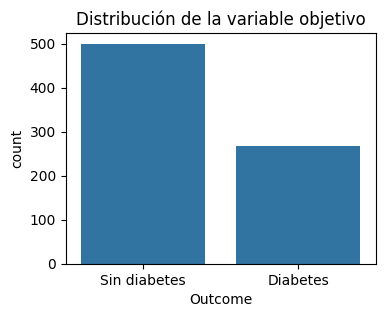

,ceros,porcentaje
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


In [33]:
# Paso 2: Balance de clases
print(df["Outcome"].value_counts().rename({0: "Sin diabetes", 1: "Diabetes"}))

plt.figure(figsize=(4, 3))
sns.countplot(x="Outcome", data=df)
plt.xticks([0, 1], ["Sin diabetes", "Diabetes"])
plt.title("Distribución de la variable objetivo")
plt.show()

# Ceros en variables donde no tienen sentido clínico (= dato faltante)
cols_cero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
faltantes = (df[cols_cero] == 0).sum().to_frame("ceros")
faltantes["porcentaje"] = (faltantes["ceros"] / len(df) * 100).round(1)
faltantes


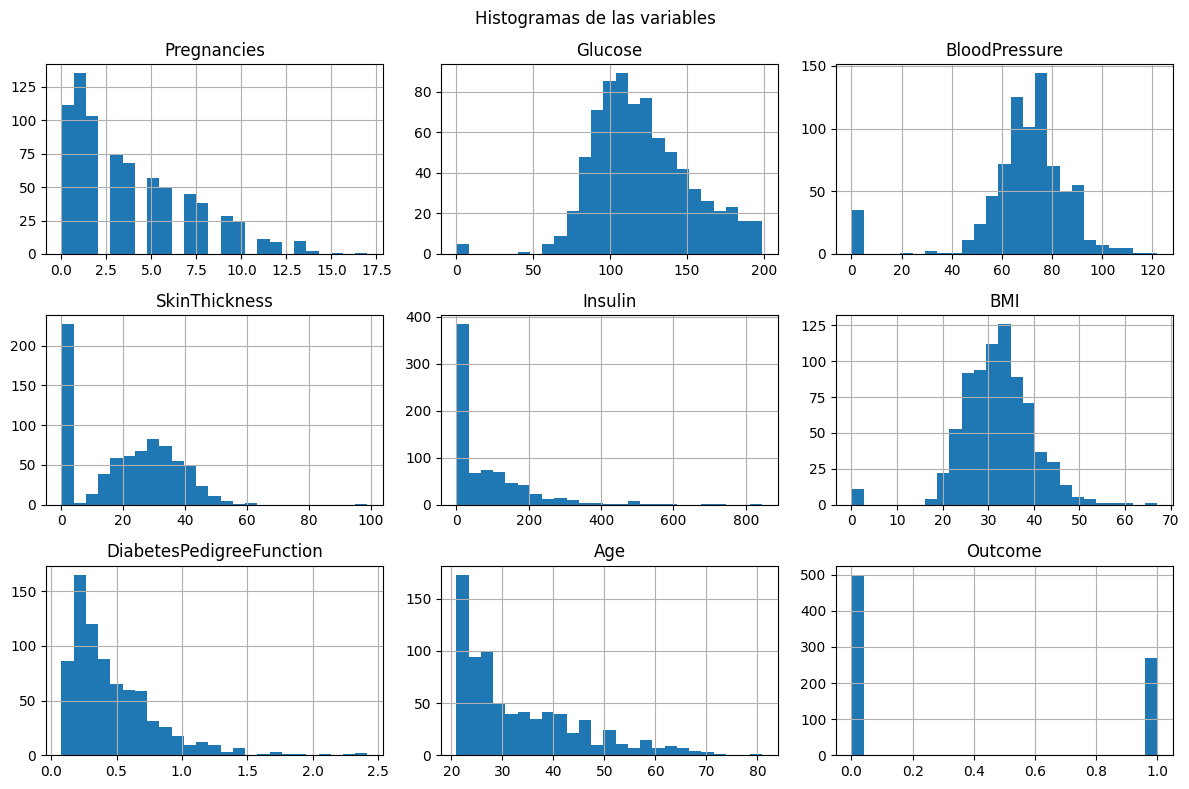

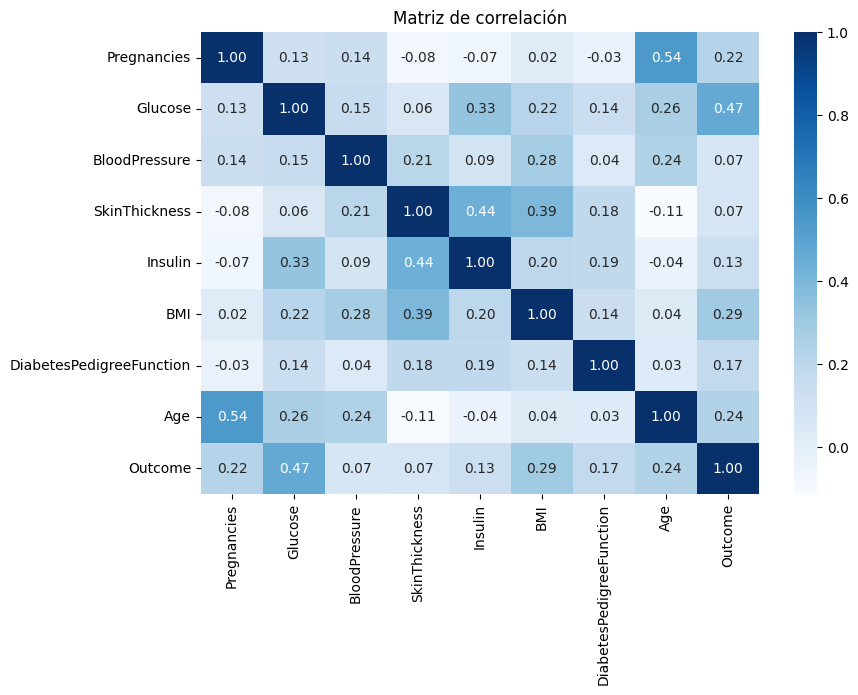

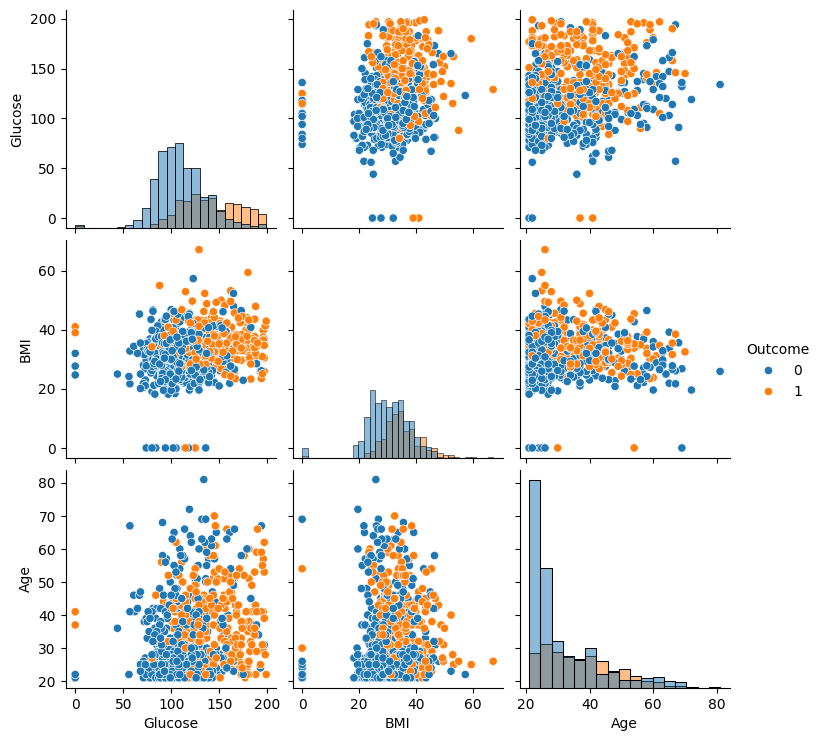

In [6]:
# Paso 3: Distribución de cada variable según la clase
df.hist(bins=25, figsize=(12, 8))
plt.suptitle("Histogramas de las variables")
plt.tight_layout()
plt.show()

# Paso 4: Matriz de correlación
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlación")
plt.show()

# Paso 5: Relación entre las variables más asociadas con el resultado
sns.pairplot(df[["Glucose", "BMI", "Age", "Outcome"]], hue="Outcome", diag_kind="hist")
plt.show()


**Hallazgos del EDA:**
- Hay desbalance moderado: aproximadamente 65 % sin diabetes y 35 % con diabetes (se compensa con `class_weight="balanced"`).
- `Glucose` es la variable más correlacionada con el resultado, seguida de `BMI`, `Age` y `Pregnancies`.
- `Insulin` (≈ 49 % de ceros) y `SkinThickness` (≈ 30 %) tienen muchísimos valores no medidos; se imputarán con la mediana dentro del `Pipeline`, de modo que la API aplique exactamente el mismo tratamiento que el entrenamiento.

## 3. Preprocesamiento, entrenamiento y evaluación del modelo

Se usa un `Pipeline` de scikit-learn: (1) imputación de los ceros con la mediana y (2) `RandomForestClassifier`. Meter el preprocesamiento **dentro** del pipeline evita el error clásico de entrenar con un tratamiento de datos y servir con otro. El script `train_model.py` (el mismo del repositorio) entrena y serializa el modelo con `joblib`.

In [7]:
%%writefile diabetes_api_project/app/train_model.py
"""
Entrena y serializa el modelo de clasificación que servirá la API.

Dataset: Pima Indians Diabetes (768 pacientes, 8 variables clínicas).
Objetivo: predecir si la paciente tiene diabetes (Outcome = 1) o no (0).

El preprocesamiento (imputación de ceros fisiológicamente imposibles)
va DENTRO del Pipeline, de modo que la API recibe los valores crudos
y aplica exactamente el mismo tratamiento que en el entrenamiento.

Genera: app/model/model.joblib y app/model/metadata.json
"""
import json
import os
from datetime import datetime, timezone

import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

BASE_DIR = os.path.dirname(__file__)
DATA_PATH = os.path.join(os.path.dirname(BASE_DIR), "data", "diabetes.csv")
MODEL_DIR = os.path.join(BASE_DIR, "model")

FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"
# En estas columnas un 0 no es un valor real (glucosa 0, BMI 0...): se trata como dato faltante.
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
TARGET_NAMES = ["Sin diabetes", "Diabetes"]


def build_pipeline() -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[
            (
                "imputar_ceros",
                SimpleImputer(missing_values=0, strategy="median"),
                ZERO_AS_MISSING,
            )
        ],
        remainder="passthrough",
    )
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
    )
    return Pipeline([("preprocesamiento", preprocess), ("modelo", model)])


def main():
    os.makedirs(MODEL_DIR, exist_ok=True)
    df = pd.read_csv(DATA_PATH)
    X, y = df[FEATURES], df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = build_pipeline()
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"accuracy={acc:.4f}  f1={f1:.4f}  roc_auc={auc:.4f}")

    joblib.dump(pipe, os.path.join(MODEL_DIR, "model.joblib"))

    metadata = {
        "model_type": "RandomForestClassifier (Pipeline con imputación de ceros)",
        "dataset": "Pima Indians Diabetes (768 registros)",
        "feature_names": FEATURES,
        "target_names": TARGET_NAMES,
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "roc_auc": round(auc, 4),
        "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }
    with open(os.path.join(MODEL_DIR, "metadata.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    print(f"Modelo guardado en {MODEL_DIR}/model.joblib")


if __name__ == "__main__":
    main()


Writing diabetes_api_project/app/train_model.py


In [8]:
!python diabetes_api_project/app/train_model.py

accuracy=0.7403  f1=0.6610  roc_auc=0.8193
Modelo guardado en /content/diabetes_api_project/app/model/model.joblib


              precision    recall  f1-score   support

Sin diabetes       0.83      0.75      0.79       100
    Diabetes       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



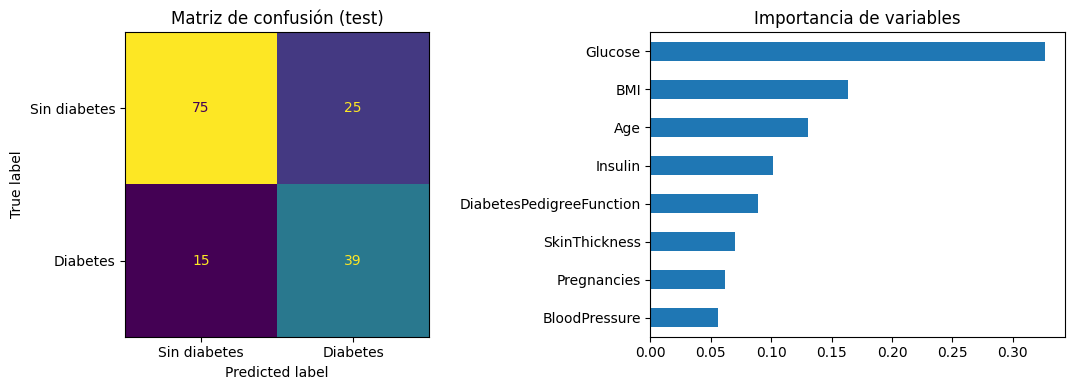

In [9]:
# Paso 6: Evaluación detallada del modelo guardado (mismo split del entrenamiento)
import sys, joblib
sys.path.insert(0, "diabetes_api_project")
from app.train_model import FEATURES, TARGET, TARGET_NAMES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

modelo = joblib.load("diabetes_api_project/app/model/model.joblib")
X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=TARGET_NAMES, ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión (test)")

# Importancia de variables (el RandomForest recibe primero las 5 columnas imputadas y luego el resto)
nombres = modelo.named_steps["preprocesamiento"].get_feature_names_out()
nombres = [n.split("__")[-1] for n in nombres]
imp = pd.Series(modelo.named_steps["modelo"].feature_importances_, index=nombres).sort_values()
imp.plot.barh(ax=axes[1])
axes[1].set_title("Importancia de variables")
plt.tight_layout()
plt.show()


**Lectura de resultados:** el modelo alcanza un accuracy cercano a 0.73 y un ROC-AUC cercano a 0.82, valores típicos para este dataset (es pequeño y ruidoso). Para el objetivo de la actividad —desplegar y monitorear el servicio— lo importante es que el modelo quede serializado y reproducible; mejorar su desempeño (tuning, otros algoritmos) sería un trabajo aparte, como el de la práctica de MLflow.

## 4. Implementación de la API REST con FastAPI

| Método | Ruta | Descripción |
|---|---|---|
| `GET` | `/health` | Estado del servicio y si el modelo está cargado |
| `GET` | `/model-info` | Metadatos del modelo (variables, clases, métricas) |
| `GET` | `/stats` | Contadores de monitoreo: solicitudes, errores 4xx/5xx, predicciones, latencia promedio |
| `POST` | `/predict` | Recibe las 8 variables clínicas y devuelve la clase predicha con su probabilidad |

La validación de entrada se hace con **Pydantic** (tipos y rangos clínicos razonables) y cada solicitud queda registrada con un `request_id` único, su entrada, resultado, código HTTP y latencia.

In [10]:
%%writefile diabetes_api_project/app/logging_config.py
"""
Configuración centralizada de logging para la API.

Escribe en consola y en logs/api.log con un formato que permite
monitorear: timestamp, nivel, módulo y mensaje (request_id, entrada,
predicción, código de estado y latencia de cada solicitud).
"""
import logging
import os

LOG_DIR = os.path.join(os.path.dirname(os.path.dirname(__file__)), "logs")
os.makedirs(LOG_DIR, exist_ok=True)
LOG_FILE = os.path.join(LOG_DIR, "api.log")


def setup_logging() -> logging.Logger:
    logger = logging.getLogger("diabetes_api")
    logger.setLevel(logging.INFO)

    if logger.handlers:
        return logger  # evita duplicar handlers si se llama más de una vez

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    file_handler = logging.FileHandler(LOG_FILE, encoding="utf-8")
    file_handler.setFormatter(fmt)

    console_handler = logging.StreamHandler()
    console_handler.setFormatter(fmt)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    return logger


Writing diabetes_api_project/app/logging_config.py


In [11]:
%%writefile diabetes_api_project/app/main.py
"""
API REST con FastAPI para servir un modelo de clasificación de diabetes
(Pipeline: imputación de ceros + RandomForestClassifier, dataset Pima).

Endpoints:
    GET  /health      -> estado del servicio y si el modelo está cargado
    GET  /model-info  -> metadatos del modelo (features, clases, métricas)
    GET  /stats       -> contadores de monitoreo básico (solicitudes, errores, latencia)
    POST /predict     -> recibe las 8 variables clínicas y devuelve la clase predicha

Incluye:
    - Validación de entrada con Pydantic (tipos y rangos clínicos razonables)
    - Logging de cada solicitud (request_id, entrada, resultado, latencia) en logs/api.log
    - Manejo de errores con códigos HTTP apropiados y registro de excepciones
"""
import json
import os
import time
import uuid
from contextlib import asynccontextmanager
from typing import Dict

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException, Request
from fastapi.exception_handlers import request_validation_exception_handler
from fastapi.exceptions import RequestValidationError
from fastapi.responses import JSONResponse
from pydantic import BaseModel, ConfigDict, Field

from app.logging_config import setup_logging

logger = setup_logging()

BASE_DIR = os.path.dirname(__file__)
MODEL_PATH = os.path.join(BASE_DIR, "model", "model.joblib")
METADATA_PATH = os.path.join(BASE_DIR, "model", "metadata.json")

# Orden y nombres de columnas con los que se entrenó el modelo
FEATURES = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age",
]

_model = None
_metadata: Dict = {}
_stats = {
    "started_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "total_requests": 0,
    "errors_4xx": 0,
    "errors_5xx": 0,
    "predictions": 0,
    "predictions_by_class": {"Sin diabetes": 0, "Diabetes": 0},
    "predict_latency_ms_total": 0.0,
}


@asynccontextmanager
async def lifespan(app: FastAPI):
    global _model, _metadata
    try:
        _model = joblib.load(MODEL_PATH)
        with open(METADATA_PATH, encoding="utf-8") as f:
            _metadata = json.load(f)
        logger.info("Modelo cargado correctamente desde %s", MODEL_PATH)
    except Exception:
        logger.exception("Error cargando el modelo durante el arranque")
        raise
    yield
    logger.info("Servicio detenido")


app = FastAPI(
    title="Diabetes Classifier API",
    description=(
        "Servicio web que expone un modelo de clasificación (RandomForest) entrenado "
        "con el dataset Pima Indians Diabetes para estimar si una paciente tiene diabetes."
    ),
    version="1.0.0",
    lifespan=lifespan,
)


class PredictRequest(BaseModel):
    model_config = ConfigDict(
        json_schema_extra={
            "example": {
                "pregnancies": 6,
                "glucose": 148,
                "blood_pressure": 72,
                "skin_thickness": 35,
                "insulin": 0,
                "bmi": 33.6,
                "diabetes_pedigree_function": 0.627,
                "age": 50,
            }
        }
    )

    pregnancies: int = Field(..., ge=0, le=20, description="Número de embarazos")
    glucose: float = Field(..., ge=0, le=300, description="Glucosa en plasma (mg/dL). 0 = no medido")
    blood_pressure: float = Field(..., ge=0, le=200, description="Presión diastólica (mm Hg). 0 = no medido")
    skin_thickness: float = Field(..., ge=0, le=100, description="Pliegue cutáneo del tríceps (mm). 0 = no medido")
    insulin: float = Field(..., ge=0, le=900, description="Insulina sérica a 2 h (mu U/ml). 0 = no medido")
    bmi: float = Field(..., ge=0, le=80, description="Índice de masa corporal. 0 = no medido")
    diabetes_pedigree_function: float = Field(..., ge=0, le=3, description="Función de antecedentes familiares de diabetes")
    age: int = Field(..., ge=1, le=120, description="Edad (años)")


class PredictResponse(BaseModel):
    request_id: str
    predicted_class: int
    predicted_label: str
    probability_diabetes: float
    latency_ms: float


@app.middleware("http")
async def log_requests(request: Request, call_next):
    """Registra cada solicitud entrante y su resultado (monitoreo básico)."""
    request_id = str(uuid.uuid4())[:8]
    request.state.request_id = request_id
    start = time.perf_counter()
    _stats["total_requests"] += 1
    logger.info("[%s] %s %s", request_id, request.method, request.url.path)
    try:
        response = await call_next(request)
    except Exception:
        _stats["errors_5xx"] += 1
        logger.exception("[%s] Error no controlado procesando la solicitud", request_id)
        return JSONResponse(
            status_code=500,
            content={"detail": "Error interno del servidor", "request_id": request_id},
        )
    elapsed_ms = (time.perf_counter() - start) * 1000
    if response.status_code >= 500:
        _stats["errors_5xx"] += 1
    elif response.status_code >= 400:
        _stats["errors_4xx"] += 1
    logger.info("[%s] status=%s tiempo=%.2fms", request_id, response.status_code, elapsed_ms)
    response.headers["X-Request-ID"] = request_id
    return response


@app.exception_handler(RequestValidationError)
async def validation_error_handler(request: Request, exc: RequestValidationError):
    """Registra como WARNING las solicitudes con datos inválidos y deja la respuesta 422 estándar."""
    errores = [f"{'.'.join(str(p) for p in e['loc'])}: {e['msg']}" for e in exc.errors()]
    logger.warning("[%s] Entrada inválida -> %s", getattr(request.state, "request_id", "-"), errores)
    return await request_validation_exception_handler(request, exc)


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": _model is not None}


@app.get("/model-info")
def model_info():
    if not _metadata:
        raise HTTPException(status_code=503, detail="Metadatos del modelo no disponibles")
    return _metadata


@app.get("/stats")
def stats():
    """Contadores de monitoreo básico desde que arrancó el servicio."""
    n = _stats["predictions"]
    avg = _stats["predict_latency_ms_total"] / n if n else 0.0
    return {
        "started_at": _stats["started_at"],
        "total_requests": _stats["total_requests"],
        "errors_4xx": _stats["errors_4xx"],
        "errors_5xx": _stats["errors_5xx"],
        "predictions": n,
        "predictions_by_class": _stats["predictions_by_class"],
        "avg_predict_latency_ms": round(avg, 3),
    }


@app.post("/predict", response_model=PredictResponse)
def predict(payload: PredictRequest, request: Request):
    request_id = request.state.request_id
    start = time.perf_counter()

    if _model is None:
        logger.error("[%s] Solicitud de predicción con el modelo no cargado", request_id)
        raise HTTPException(status_code=503, detail="Modelo no disponible")

    try:
        d = payload.model_dump()
        row = pd.DataFrame(
            [[
                d["pregnancies"], d["glucose"], d["blood_pressure"], d["skin_thickness"],
                d["insulin"], d["bmi"], d["diabetes_pedigree_function"], d["age"],
            ]],
            columns=FEATURES,
        )
        pred_class = int(_model.predict(row)[0])
        proba = float(_model.predict_proba(row)[0][1])
        label = _metadata["target_names"][pred_class]

        elapsed_ms = (time.perf_counter() - start) * 1000
        _stats["predictions"] += 1
        _stats["predictions_by_class"][label] += 1
        _stats["predict_latency_ms_total"] += elapsed_ms
        logger.info(
            "[%s] predicción OK: input=%s -> %s (p_diabetes=%.3f)",
            request_id, d, label, proba,
        )

        return PredictResponse(
            request_id=request_id,
            predicted_class=pred_class,
            predicted_label=label,
            probability_diabetes=round(proba, 4),
            latency_ms=round(elapsed_ms, 3),
        )
    except Exception:
        logger.exception("[%s] Error generando la predicción para input=%s", request_id, payload)
        raise HTTPException(status_code=500, detail="Error al generar la predicción")


Writing diabetes_api_project/app/main.py


## 5. Levantar el servicio

`uvicorn` se ejecuta como proceso independiente en segundo plano, de modo que el notebook puede seguir ejecutando celdas (pruebas con curl) mientras el servicio está activo.

In [12]:
import subprocess, sys, time

uvicorn_proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"],
    cwd="diabetes_api_project",
    stdout=open("uvicorn_stdout.log", "w"),
    stderr=subprocess.STDOUT,
)
time.sleep(4)
print("Servicio iniciado. PID:", uvicorn_proc.pid)


Servicio iniciado. PID: 2353


In [13]:
import requests

r = requests.get("http://localhost:8000/health", timeout=5)
print(r.status_code, r.json())

200 {'status': 'ok', 'model_loaded': True}


**En Google Colab** el servicio corre dentro de la máquina virtual de Colab. Para consumirlo desde Postman en tu propio computador hay que exponerlo públicamente: con el proxy nativo de Colab (sin cuentas ni tokens) o con ngrok usando tu propio *authtoken* de ngrok (nunca una clave de otro servicio). Las celdas están comentadas porque solo aplican en Colab:

In [ ]:
# Ejecutar únicamente en Google Colab
# Opción A (recomendada): proxy nativo de Colab
# from google.colab.output import eval_js
# print(eval_js("google.colab.kernel.proxyPort(8000)"))

# Opción B: ngrok
# !pip install -q pyngrok
# from pyngrok import ngrok
# ngrok.set_auth_token("TU_AUTHTOKEN_DE_NGROK")  # desde dashboard.ngrok.com
# print(ngrok.connect(8000))


## 6. Pruebas de la API con curl

Se prueban los cuatro endpoints, con casos válidos y casos de error. Cada respuesta incluye el encabezado `x-request-id`, que permite rastrear la solicitud en el log.

In [14]:
!echo "=== 1) GET /health ===" && \
curl -s -i http://localhost:8000/health

=== 1) GET /health ===
HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 23:51:35 GMT
server: uvicorn
content-length: 35
content-type: application/json
x-request-id: 47c6b0df

{"status":"ok","model_loaded":true}

In [15]:
!echo "=== 2) GET /model-info ===" && \
curl -s -i http://localhost:8000/model-info

=== 2) GET /model-info ===
HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 23:51:38 GMT
server: uvicorn
content-length: 378
content-type: application/json
x-request-id: 5ff0549b

{"model_type":"RandomForestClassifier (Pipeline con imputación de ceros)","dataset":"Pima Indians Diabetes (768 registros)","feature_names":["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"],"target_names":["Sin diabetes","Diabetes"],"accuracy":0.7403,"f1":0.661,"roc_auc":0.8193,"trained_at":"2026-10-07T23:50:52+00:00"}

In [16]:
!echo "=== 3) POST /predict - paciente con perfil de riesgo alto ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":6,"glucose":148,"blood_pressure":72,"skin_thickness":35,"insulin":0,"bmi":33.6,"diabetes_pedigree_function":0.627,"age":50}'

=== 3) POST /predict - paciente con perfil de riesgo alto ===
HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 23:51:40 GMT
server: uvicorn
content-length: 124
content-type: application/json
x-request-id: 9329a957

{"request_id":"9329a957","predicted_class":1,"predicted_label":"Diabetes","probability_diabetes":0.7992,"latency_ms":28.632}

In [17]:
!echo "=== 4) POST /predict - paciente con perfil de riesgo bajo ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":1,"glucose":85,"blood_pressure":66,"skin_thickness":29,"insulin":0,"bmi":26.6,"diabetes_pedigree_function":0.351,"age":31}'

=== 4) POST /predict - paciente con perfil de riesgo bajo ===
HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 23:51:41 GMT
server: uvicorn
content-length: 128
content-type: application/json
x-request-id: fb48e726

{"request_id":"fb48e726","predicted_class":0,"predicted_label":"Sin diabetes","probability_diabetes":0.1206,"latency_ms":23.862}

In [18]:
!echo "=== 5) POST /predict - valores 0 (dato no medido, se imputa con la mediana) ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":2,"glucose":0,"blood_pressure":0,"skin_thickness":0,"insulin":0,"bmi":0,"diabetes_pedigree_function":0.5,"age":40}'

=== 5) POST /predict - valores 0 (dato no medido, se imputa con la mediana) ===
HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 23:51:43 GMT
server: uvicorn
content-length: 124
content-type: application/json
x-request-id: ff6bcf10

{"request_id":"ff6bcf10","predicted_class":1,"predicted_label":"Diabetes","probability_diabetes":0.6037,"latency_ms":24.635}

In [19]:
!echo "=== 6) POST /predict - error de validación (edad negativa) ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":2,"glucose":120,"blood_pressure":70,"skin_thickness":20,"insulin":80,"bmi":30,"diabetes_pedigree_function":0.5,"age":-3}'

=== 6) POST /predict - error de validación (edad negativa) ===
HTTP/1.1 422 Unprocessable Content
date: Wed, 07 Oct 2026 23:51:45 GMT
server: uvicorn
content-length: 140
content-type: application/json
x-request-id: 67469d89

{"detail":[{"type":"greater_than_equal","loc":["body","age"],"msg":"Input should be greater than or equal to 1","input":-3,"ctx":{"ge":1}}]}

In [20]:
!echo "=== 7) POST /predict - error (falta el campo bmi) ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":2,"glucose":120,"blood_pressure":70,"skin_thickness":20,"insulin":80,"diabetes_pedigree_function":0.5,"age":40}'

=== 7) POST /predict - error (falta el campo bmi) ===
HTTP/1.1 422 Unprocessable Content
date: Wed, 07 Oct 2026 23:51:47 GMT
server: uvicorn
content-length: 210
content-type: application/json
x-request-id: efa6fb63

{"detail":[{"type":"missing","loc":["body","bmi"],"msg":"Field required","input":{"pregnancies":2,"glucose":120,"blood_pressure":70,"skin_thickness":20,"insulin":80,"diabetes_pedigree_function":0.5,"age":40}}]}

In [21]:
!echo "=== 8) POST /predict - error (tipo inválido: glucose como texto) ===" && \
curl -s -i -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"pregnancies":2,"glucose":"alta","blood_pressure":70,"skin_thickness":20,"insulin":80,"bmi":30,"diabetes_pedigree_function":0.5,"age":40}'

=== 8) POST /predict - error (tipo inválido: glucose como texto) ===
HTTP/1.1 422 Unprocessable Content
date: Wed, 07 Oct 2026 23:51:48 GMT
server: uvicorn
content-length: 152
content-type: application/json
x-request-id: ffa37287

{"detail":[{"type":"float_parsing","loc":["body","glucose"],"msg":"Input should be a valid number, unable to parse string as a number","input":"alta"}]}

**Resumen de resultados esperados / obtenidos:**

| Prueba | Resultado |
|---|---|
| `/health`, `/model-info` | `200 OK` |
| Perfil de riesgo alto | `200` → `Diabetes` (probabilidad ≈ 0.80) |
| Perfil de riesgo bajo | `200` → `Sin diabetes` (probabilidad ≈ 0.13) |
| Variables en 0 (no medidas) | `200` → se imputan con la mediana y el servicio responde sin fallar |
| Edad negativa / campo faltante / texto en un campo numérico | `422` con el detalle del campo que falló |


### Capturas de pantalla de las pruebas (Swagger UI en `/docs`)

FastAPI genera automáticamente una interfaz interactiva en `/docs`. Estas capturas muestran la pantalla principal y las pruebas ejecutadas desde ahí.

**Endpoints documentados automáticamente:**

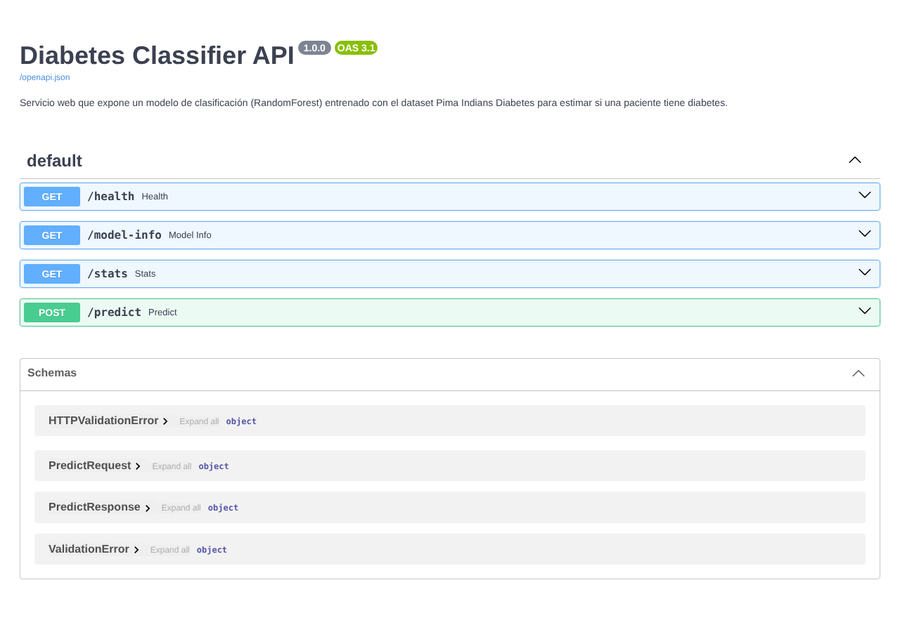

**`POST /predict` con datos válidos (200 OK):**

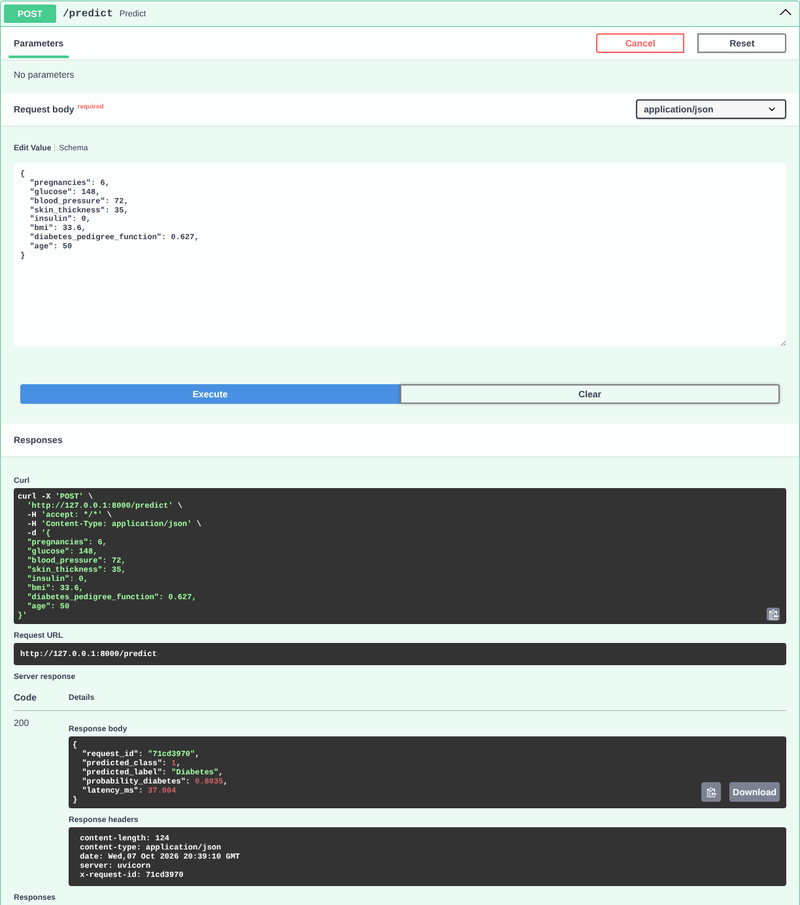

**`POST /predict` con edad = -3 (422, validación):**

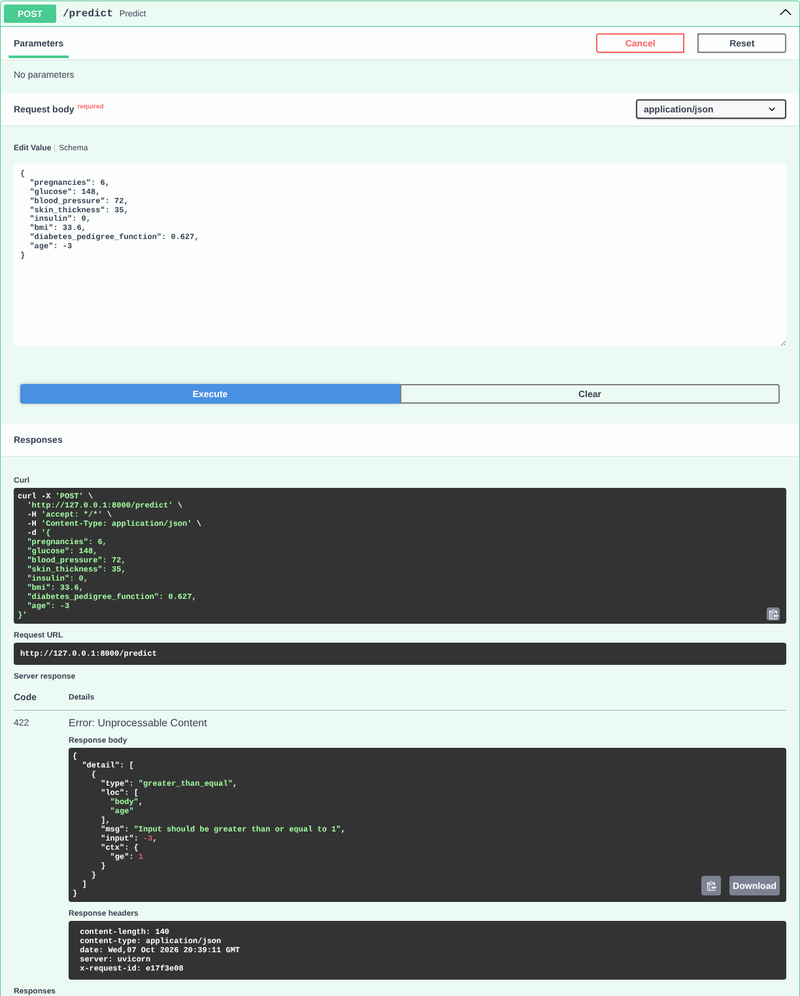

> **Prueba equivalente con Postman:** el repositorio incluye la colección `tests/postman_collection.json` con las mismas pruebas, lista para importar (*File → Import*). Basta apuntar la variable `base_url` a `http://localhost:8000` (o a la URL pública si se expone desde Colab).

## 7. Registro de eventos y monitoreo básico

**Registro (`logs/api.log`).** Cada solicitud deja trazas con su `request_id`: método y ruta, datos de entrada, predicción, código de estado y latencia. Las entradas inválidas se registran como `WARNING` y los errores no controlados como `ERROR` con su traceback.

In [25]:
with open("diabetes_api_project/logs/api.log", encoding="utf-8") as f:
    print(f.read())

2026-10-07 23:51:12 | INFO | diabetes_api | Modelo cargado correctamente desde /content/diabetes_api_project/app/model/model.joblib
2026-10-07 23:51:19 | INFO | diabetes_api | [a2624fb8] GET /health
2026-10-07 23:51:19 | INFO | diabetes_api | [a2624fb8] status=200 tiempo=1.65ms
2026-10-07 23:51:35 | INFO | diabetes_api | [47c6b0df] GET /health
2026-10-07 23:51:35 | INFO | diabetes_api | [47c6b0df] status=200 tiempo=0.83ms
2026-10-07 23:51:38 | INFO | diabetes_api | [5ff0549b] GET /model-info
2026-10-07 23:51:38 | INFO | diabetes_api | [5ff0549b] status=200 tiempo=0.80ms
2026-10-07 23:51:40 | INFO | diabetes_api | [9329a957] POST /predict
2026-10-07 23:51:40 | INFO | diabetes_api | [9329a957] predicción OK: input={'pregnancies': 6, 'glucose': 148.0, 'blood_pressure': 72.0, 'skin_thickness': 35.0, 'insulin': 0.0, 'bmi': 33.6, 'diabetes_pedigree_function': 0.627, 'age': 50} -> Diabetes (p_diabetes=0.799)
2026-10-07 23:51:40 | INFO | diabetes_api | [9329a957] status=200 tiempo=31.21ms
2026

**Monitoreo (`GET /stats`).** Contadores en memoria desde que arrancó el servicio: total de solicitudes, errores 4xx y 5xx, predicciones por clase y latencia promedio. Un aumento sostenido de errores 4xx apunta a clientes enviando datos malos; los 5xx, a fallas del propio servicio.

In [30]:
!curl -s http://localhost:8000/stats | python -m json.tool

Expecting value: line 1 column 1 (char 0)


## 8. Detener el servicio

In [31]:
uvicorn_proc.terminate()
uvicorn_proc.wait(timeout=10)
print("Servicio detenido.")

Servicio detenido.


## 9. Conclusiones

- Se entrenó y serializó un clasificador de diabetes (`Pipeline` con imputación de ceros + `RandomForestClassifier`, accuracy ≈ 0.73, ROC-AUC ≈ 0.82) y se desplegó como servicio REST con FastAPI, con documentación interactiva automática en `/docs`.
- Incluir el preprocesamiento dentro del `Pipeline` garantiza que la API trate los datos igual que en el entrenamiento: los valores en 0 (no medidos) se imputan en lugar de distorsionar la predicción.
- Las pruebas con curl y Swagger UI confirmaron respuestas correctas (`200`) en los casos válidos y rechazo controlado (`422`) de entradas inválidas (valor fuera de rango, campo faltante, tipo incorrecto), sin afectar la disponibilidad del servicio.
- El registro de eventos y el endpoint `/stats` permiten monitorear el servicio y detectar errores: cada solicitud queda trazada por `request_id`, y los contadores de errores 4xx/5xx y la latencia dan una vista rápida de su estado.
- Cualquier aplicación puede integrar el modelo con una simple petición HTTP a `/predict`, sin conocer el modelo ni el entorno de Python en que fue entrenado.

**Limitaciones y mejoras posibles:** el modelo es didáctico (dataset pequeño, sin ajuste de hiperparámetros) y los contadores de `/stats` viven en memoria; en producción se usarían herramientas como Prometheus/Grafana, autenticación en la API y un contenedor Docker para el despliegue.